## Import Library

In [1]:
import os
import cv2
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_recall_fscore_support, classification_report

## Dataset Exploration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Direktori yang menyimpan data
DATA_DIR = '/content/drive/MyDrive/genderDataset/train'

# Subdirektori untuk setiap kelas
data_dir_male = os.path.join(DATA_DIR, 'male')
data_dir_female = os.path.join(DATA_DIR, 'female')

# os.listdir mengembalikan daftar yang berisi semua file di bawah direktori yang diberikan
print(f"There is {len(os.listdir(data_dir_male))} images of Male.")
print(f"There is {len(os.listdir(data_dir_female))} images of Female.")

There is 2000 images of Male.
There is 2000 images of Female.


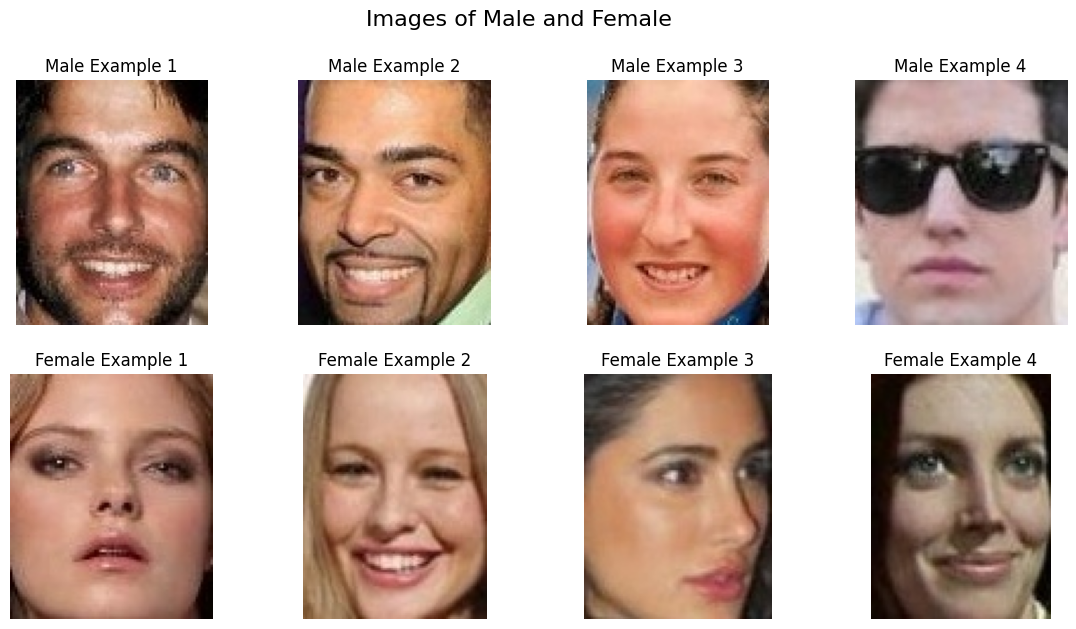

In [4]:
male_filenames = [os.path.join(data_dir_male, filename) for filename in os.listdir(data_dir_male)]
female_filenames = [os.path.join(data_dir_female, filename) for filename in os.listdir(data_dir_female)]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Images of Male and Female', fontsize=16)

for i, male_image in enumerate(male_filenames[:4]):
    img = tf.keras.utils.load_img(male_image)
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Male Example {i+1}')

for i, female_image in enumerate(female_filenames[:4]):
    img = tf.keras.utils.load_img(female_image)
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Female Example {i+1}')

plt.show()

## Pre Processing

In [5]:
def train_val_datasets():

    training_dataset, validation_dataset = tf.keras.utils.image_dataset_from_directory(
        directory=DATA_DIR,
        image_size=(120,120),
        batch_size=128,
        label_mode='binary',
        validation_split=0.1,
        subset='both',
        seed=42
    )

    return training_dataset, validation_dataset

In [6]:
# Membagi dataset
training_dataset, validation_dataset = train_val_datasets()

Found 4000 files belonging to 2 classes.
Using 3600 files for training.
Using 400 files for validation.


In [8]:
# First batch gambar dan label
for images, labels in training_dataset.take(1):
	example_batch_images = images
	example_batch_labels = labels

print(f"Maximum pixel value of images: {np.max(example_batch_images)}\n")
print(f"Shape of batch of images: {example_batch_images.shape}")
print(f"Shape of batch of labels: {example_batch_labels.shape}")

Maximum pixel value of images: 255.0

Shape of batch of images: (128, 120, 120, 3)
Shape of batch of labels: (128, 1)


## Model Augmentation

In [9]:
def create_augmentation_model():

    augmentation_model = tf.keras.Sequential([
		tf.keras.Input(shape=(120,120,3)),
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.2, fill_mode='nearest'),
        tf.keras.layers.RandomTranslation(0.2,0.2, fill_mode='nearest'),
        tf.keras.layers.RandomZoom(0.2, fill_mode='nearest')
    ])

    return augmentation_model

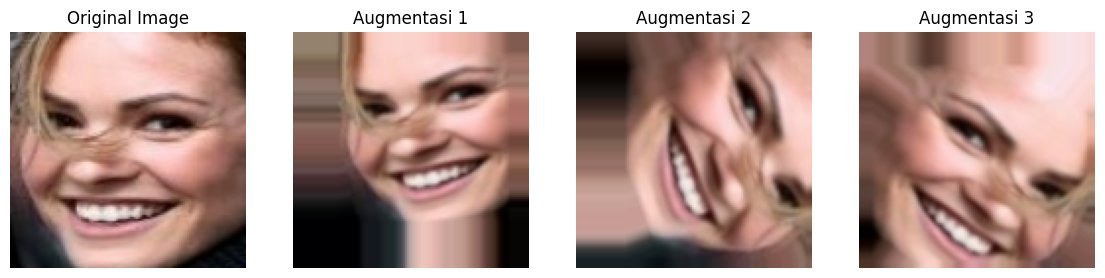

In [10]:
# Muat model untuk augmentasi
data_augmentor = create_augmentation_model()

# Ambil contoh gambar
sample_image = tf.keras.utils.array_to_img(example_batch_images[0])

images = [sample_image]

# Terapkan augmentasi acak 3 kali
for _ in range(3):
	image_aug = data_augmentor(tf.expand_dims(sample_image, axis=0))
	image_aug = tf.keras.utils.array_to_img(tf.squeeze(image_aug))
	images.append(image_aug)


fig, axs = plt.subplots(1, 4, figsize=(14, 7))
for ax, image, title in zip(axs, images, ['Original Image', 'Augmentasi 1', 'Augmentasi 2', 'Augmentasi 3']):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.show()

## Create Model

In [11]:
def create_model():

    augmentation_layers = create_augmentation_model()

    model = tf.keras.models.Sequential([
		tf.keras.Input(shape=(120, 120, 3)),
        augmentation_layers,
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
	)

    return model

In [12]:
model = create_model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 120, 120, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 120, 120, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 118, 118, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 59, 59, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 57, 57, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,710,529 (98.08 MB)

 Trainable params: 25,710,529 (98.08 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
try:
	model.evaluate(example_batch_images, example_batch_labels, verbose=False)
except:
	print("Your model is not compatible with the dataset you defined earlier. Check that the loss function, last layer and label_mode are compatible with one another.")
else:
	predictions = model.predict(example_batch_images, verbose=False)
	print(f"predictions have shape: {predictions.shape}")

predictions have shape: (128, 1)


## Train Model

In [14]:
# Latih model dan simpan riwayat pelatihan
history = model.fit(
	training_dataset,
	epochs=50,
	validation_data=validation_dataset
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 364s 12s/step - accuracy: 0.5179 - loss: 9.6581 - val_accuracy: 0.4950 - val_loss: 6.1497
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.5450 - loss: 5.3998 - val_accuracy: 0.6175 - val_loss: 3.6749
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.6131 - loss: 3.3400 - val_accuracy: 0.6850 - val_loss: 2.5173
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.6371 - loss: 2.3728 - val_accuracy: 0.5800 - val_loss: 2.0028
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 201s 5s/step - accuracy: 0.6328 - loss: 1.9130 - val_accuracy: 0.5875 - val_loss: 1.7105
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 199s 5s/step - accuracy: 0.6377 - loss: 1.6368 - val_accuracy: 0.6975 - val_loss: 1.4512
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.6426 - loss: 1.4545 - val_accuracy: 0.7175 - val_loss: 1.2981
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.6504 - loss: 1.3163 - val_accuracy: 0.7175 - 

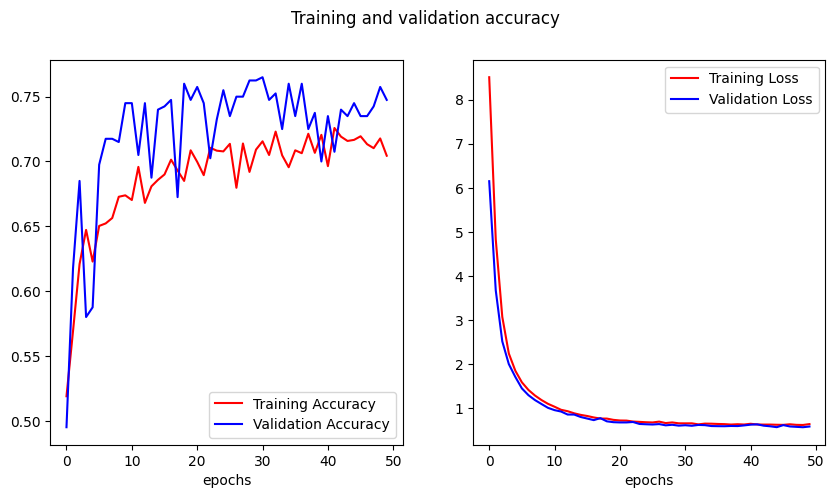

In [15]:
# Get training and validation accuracies
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Training and validation accuracy')

for i, (data, label) in enumerate(zip([(acc, val_acc), (loss, val_loss)], ["Accuracy", "Loss"])):
    ax[i].plot(epochs, data[0], 'r', label="Training " + label)
    ax[i].plot(epochs, data[1], 'b', label="Validation " + label)
    ax[i].legend()
    ax[i].set_xlabel('epochs')

plt.show()

 ## Test Dataset

In [16]:
test_dir = '/content/drive/MyDrive/genderDataset/test'

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(120, 120),
    batch_size=128,
    class_mode='binary',
    shuffle=False
)

Found 1000 images belonging to 2 classes.


## Prediction

In [17]:
from sklearn.metrics import roc_curve

# Membuat prediksi
y_true = test_generator.classes  # Label asli
y_pred = model.predict(test_generator)  # Prediksi probabilitas

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold}")

# Konversi probabilitas ke label (0 atau 1)
threshold = optimal_threshold
y_pred_labels = (y_pred > threshold).astype(int)


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 198s 28s/step
Optimal Threshold: 0.5351437926292419


In [18]:
# Hitung metrik evaluasi
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_labels, labels=[0, 1])

# Tampilkan hasil
print(f"Precision (Male): {precision[0]:.4f}")
print(f"Recall (Male): {recall[0]:.4f}")
print(f"F1-score (Male): {f1[0]:.4f}")
print(f"Precision (Female): {precision[1]:.4f}")
print(f"Recall (Female): {recall[1]:.4f}")
print(f"F1-score (Female): {f1[1]:.4f}")


Precision (Male): 0.7219
Recall (Male): 0.7060
F1-score (Male): 0.7139
Precision (Female): 0.7123
Recall (Female): 0.7280
F1-score (Female): 0.7201


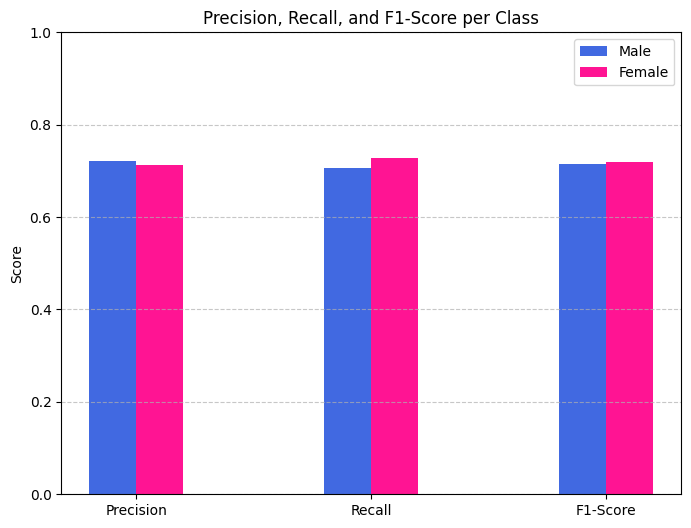

In [19]:
# Data untuk grafik
metrics = ['Precision', 'Recall', 'F1-Score']
male_scores = [precision[0], recall[0], f1[0]]
female_scores = [precision[1], recall[1], f1[1]]

x = range(len(metrics))  # Posisi x-axis

# Plot grafik batang
plt.figure(figsize=(8, 6))
bar_width = 0.2  # Lebar batang yang lebih kurus
plt.bar(x, male_scores, width=bar_width, label='Male', color='royalblue', align='center')
plt.bar([p + bar_width for p in x], female_scores, width=bar_width, label='Female', color='deeppink', align='center')

# Label dan judul
plt.xticks([p + bar_width / 2 for p in x], metrics)  # Pusatkan label x-axis
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score per Class')
plt.ylim(0, 1)  # Atur skor maksimal 1.0
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Mean Squared Error

In [20]:
# Get true labels for the validation dataset
true_labels = np.concatenate([y.numpy() for x, y in validation_dataset], axis=0)

# Assuming 'model' is your trained model and 'validation_dataset' is your validation data
predictions = model.predict(validation_dataset)  # Get raw predictions
predictions_rounded = (predictions > 0.5).astype(int) # Round predictions to 0 or 1

# Calculate MSE (though typically accuracy is used for binary classification)
mse = mean_squared_error(true_labels, predictions_rounded)
print(f"Mean Squared Error: {mse}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 673ms/step
Mean Squared Error: 0.2525


## Confusion Matrix

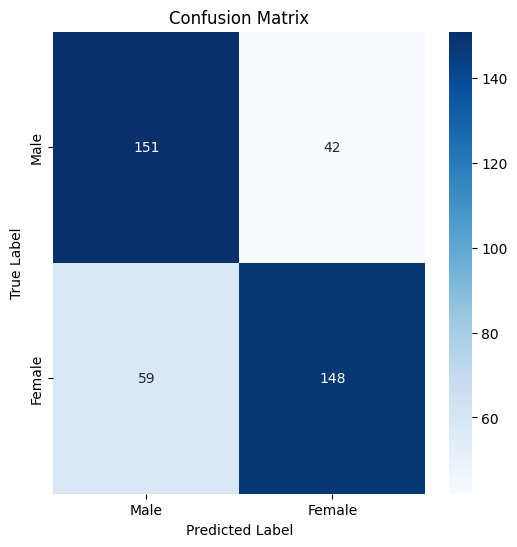

In [21]:
# Calculate the confusion matrix
cm = confusion_matrix(true_labels, predictions_rounded)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Save Model

In [22]:
model.save('genderClassification.keras')

## Convert to tfLite

In [23]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('/content/drive/MyDrive/genderClassification.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp3eyaqi88'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 120, 3), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135263446048384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263446048032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263446053840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263446050496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263447399968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263446041696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263445527264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263446042928: TensorSpec(shape=(), dtype=tf.resource, name=None)
